# 3. Evaluate all trained models

Scans `weights/` for every backbone that's been trained (has a
`best_model.pth`), loads each one, runs it on the held-out test set, and
reports/plots metrics for all of them.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys, os
DRIVE_ROOT = "/content/drive/MyDrive/comparison/boilerplate/"
sys.path.append(DRIVE_ROOT)

import fer_common as fc
paths = fc.get_paths(DRIVE_ROOT)


Mounted at /content/drive


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
)

BATCH_SIZE = 64
class_names = fc.load_class_names(paths)


## Copy test set from Drive to local disk (once per session)

In [3]:
import shutil

LOCAL_TEST_DIR = "/content/data/test"

if not os.path.exists(LOCAL_TEST_DIR):
    print("Copying test set from Drive to local disk...")
    shutil.copytree(paths["test_dir"], LOCAL_TEST_DIR)
    print("Done.")
else:
    print("Local data already present, skipping copy.")


Copying test set from Drive to local disk...
Done.


## Find every backbone that's actually been trained

In [4]:
available = []
for cfg in fc.MODEL_CONFIGS:
    ckpt_path = os.path.join(paths["weights_dir"], cfg["name"], "best_model.pth")
    if os.path.exists(ckpt_path):
        available.append(cfg)
    else:
        print(f"Skipping {cfg['name']} — no checkpoint found yet")

print("\nWill evaluate:", [c["name"] for c in available])



Will evaluate: ['inception_v3', 'densenet121', 'shufflenet_v2_x2_0', 'resnet18', 'regnet_y_400mf', 'mobilenet_v3_small', 'googlenet', 'efficientnet_v2_s', 'alexnet']


## Evaluation helper

`pretrained=False` skips downloading ImageNet weights entirely — we're
about to overwrite every parameter with the fine-tuned checkpoint anyway,
so there's no point paying for the download.

In [5]:
def load_trained_model(cfg, num_classes):
    ckpt_path = os.path.join(paths["weights_dir"], cfg["name"], "best_model.pth")
    net = fc.BackboneClassifier(cfg["fn"], num_classes=num_classes, pretrained=False)
    net.load_state_dict(torch.load(ckpt_path, map_location=net.device))
    net.eval()
    return net


def make_test_loader(input_size, batch_size=BATCH_SIZE):
    test_tf = fc.build_transforms(input_size, train=False)
    test_dataset = datasets.ImageFolder(LOCAL_TEST_DIR, transform=test_tf)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True)
    return test_loader, test_dataset.classes


def evaluate_and_plot(cfg):
    name = cfg["name"]

    try:
        net = load_trained_model(cfg, num_classes=len(class_names))
        test_loader, test_class_names = make_test_loader(cfg["input_size"])

        accuracy, all_predicted, all_targets, all_outputs = net.test_(test_loader)

        f1 = f1_score(all_targets, all_predicted, average="weighted")
        precision = precision_score(all_targets, all_predicted, average="weighted")
        recall = recall_score(all_targets, all_predicted, average="weighted")

        print("=" * 40)
        print(f"  Model         : {name}")
        print(f"  Test Accuracy : {accuracy:.4f}")
        print(f"  F1 Score      : {f1:.4f}")
        print(f"  Precision     : {precision:.4f}")
        print(f"  Recall        : {recall:.4f}")
        print("=" * 40)

        cm = confusion_matrix(
            all_targets,
            all_predicted,
            labels=range(len(test_class_names))
        )

        # Avoid division-by-zero for classes with no test samples
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(
            cm.astype(float),
            row_sums,
            out=np.zeros_like(cm, dtype=float),
            where=row_sums != 0
        )

        # Raw confusion matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=test_class_names,
            yticklabels=test_class_names
        )
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(f"Confusion Matrix (Raw Counts) — {name}")
        plt.tight_layout()
        plt.show()
        plt.close()

        # Normalized confusion matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            cm_norm,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=test_class_names,
            yticklabels=test_class_names,
            vmin=0,
            vmax=1
        )
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(f"Confusion Matrix (Row Normalised) — {name}")
        plt.tight_layout()
        plt.show()
        plt.close()

        # Classification report
        report_dict = classification_report(
            all_targets,
            all_predicted,
            target_names=test_class_names,
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(report_dict).transpose()
        report_df = report_df.drop(columns=["support"])
        report_df = report_df.loc[test_class_names]

        plt.figure(figsize=(10, 6))
        sns.heatmap(
            report_df,
            annot=True,
            cmap="viridis",
            fmt=".2f",
            vmin=0,
            vmax=1
        )
        plt.title(f"Classification Report Heatmap — {name}")
        plt.ylabel("Class")
        plt.xlabel("Metrics")
        plt.tight_layout()
        plt.show()
        plt.close()

        return {
            "name": name,
            "accuracy": accuracy,
            "f1": f1,
            "precision": precision,
            "recall": recall
        }

    except Exception as e:
        print("\n" + "!" * 60)
        print(f"ERROR evaluating model: {name}")
        print(f"Error type: {type(e).__name__}")
        print(f"Error: {e}")
        print("Skipping this model and moving to the next one...")
        print("!" * 60 + "\n")

        return None

/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of wo

  Model         : inception_v3
  Test Accuracy : 0.2707
  F1 Score      : 0.2241
  Precision     : 0.4038
  Recall        : 0.2707


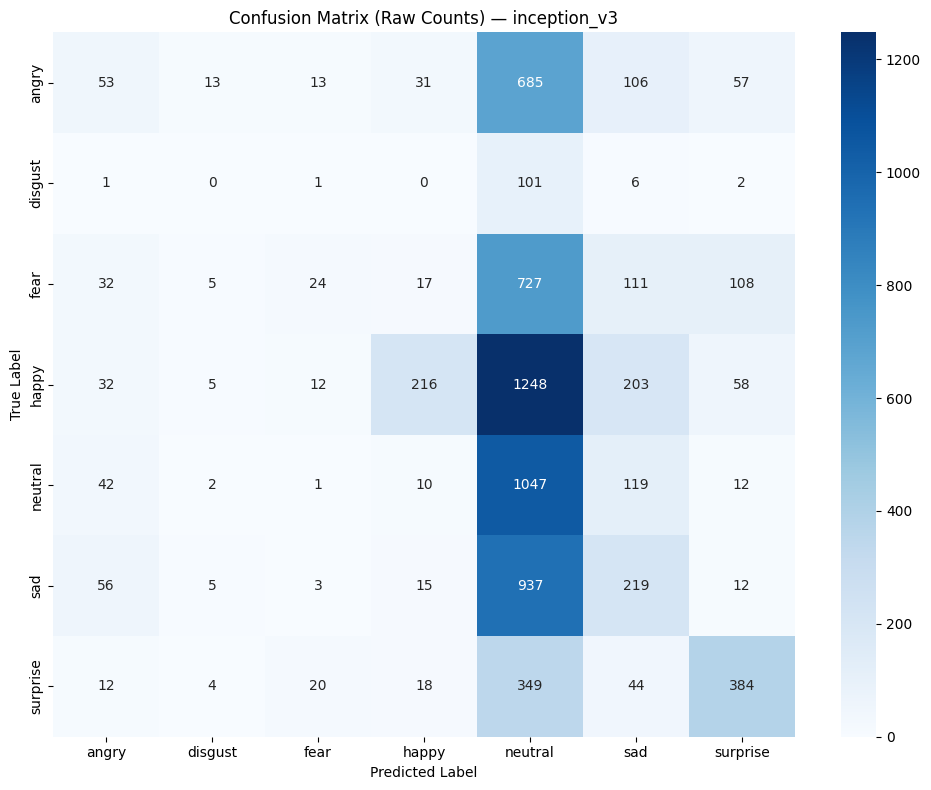

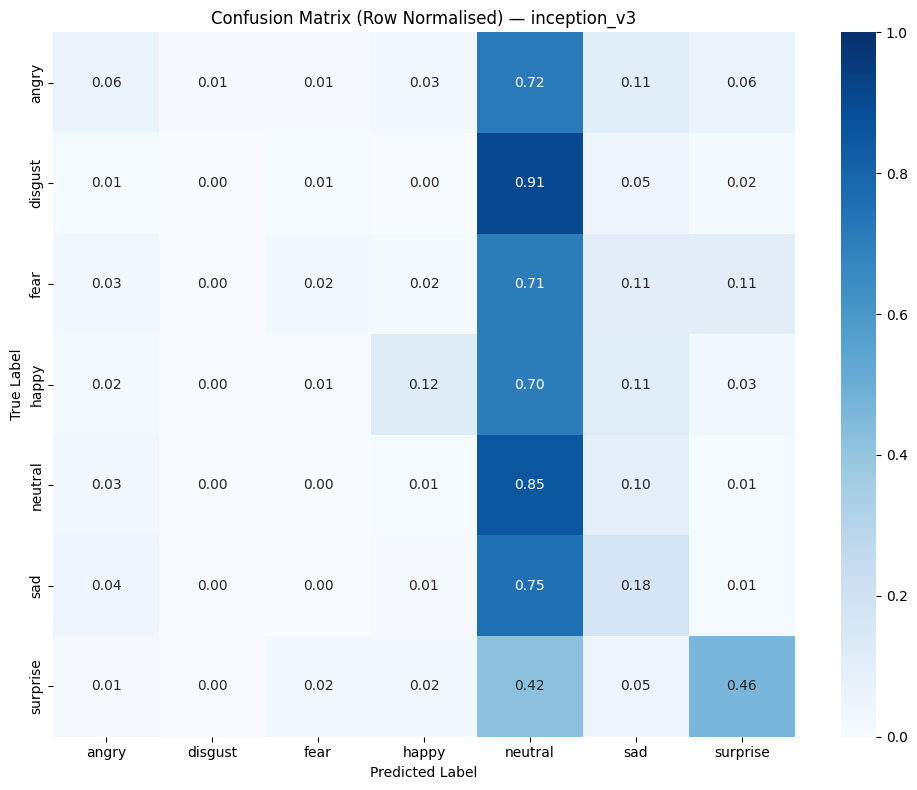

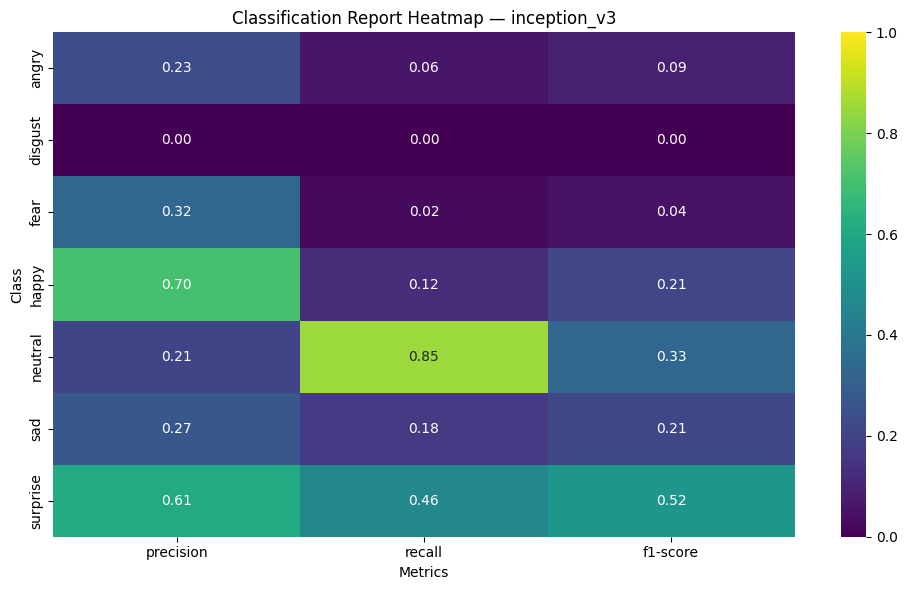

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Model         : densenet121
  Test Accuracy : 0.6925
  F1 Score      : 0.6924
  Precision     : 0.6970
  Recall        : 0.6925


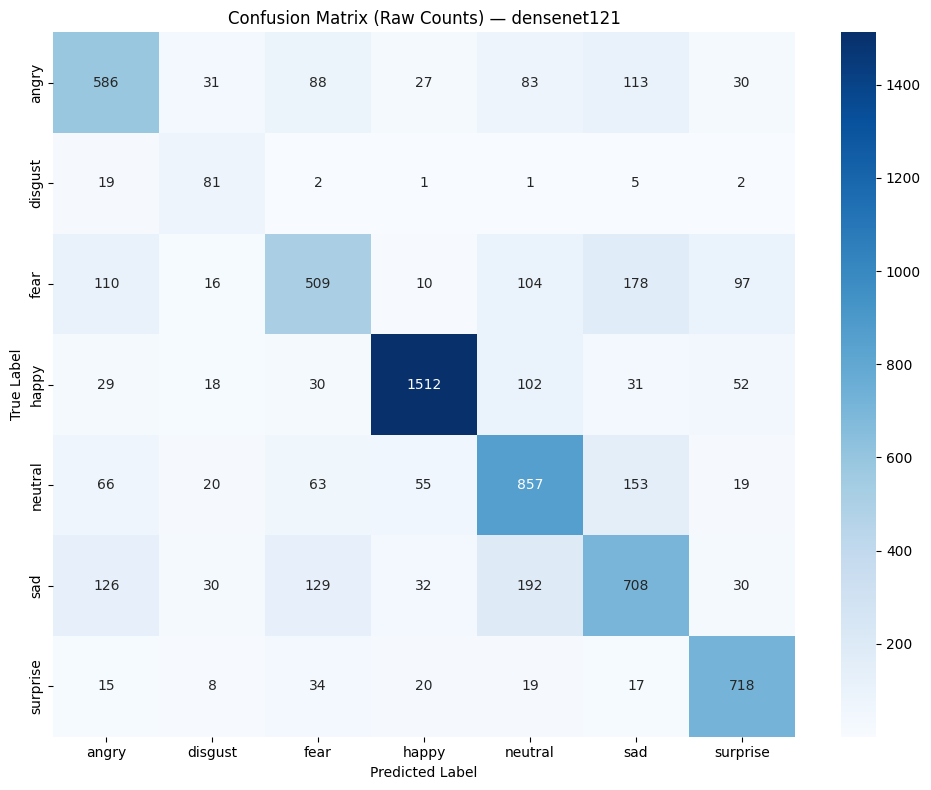

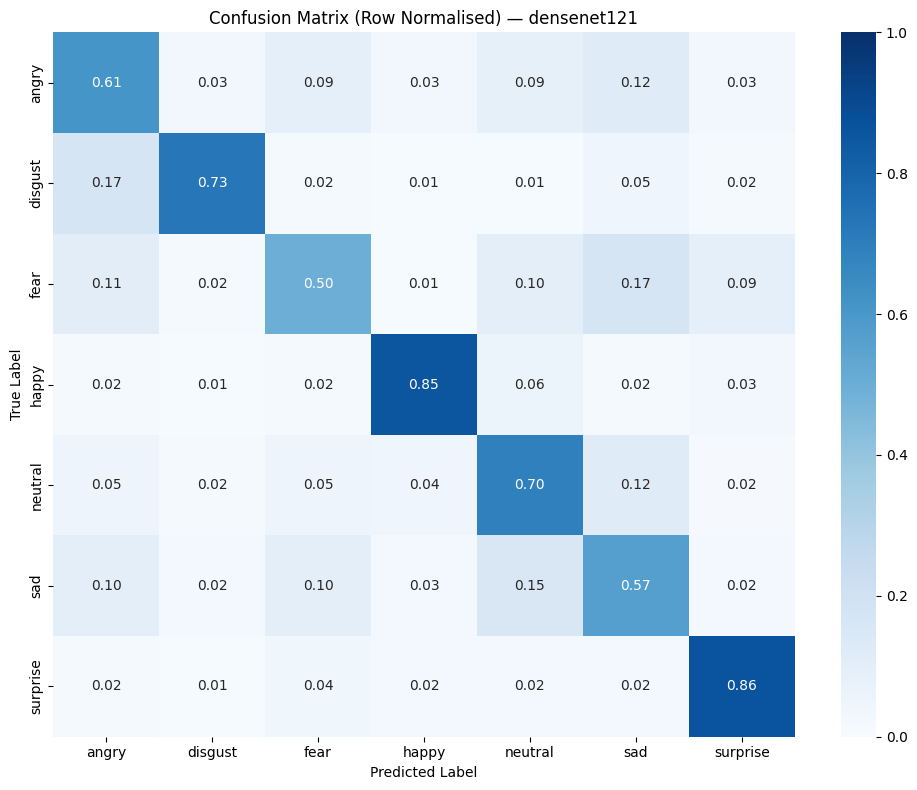

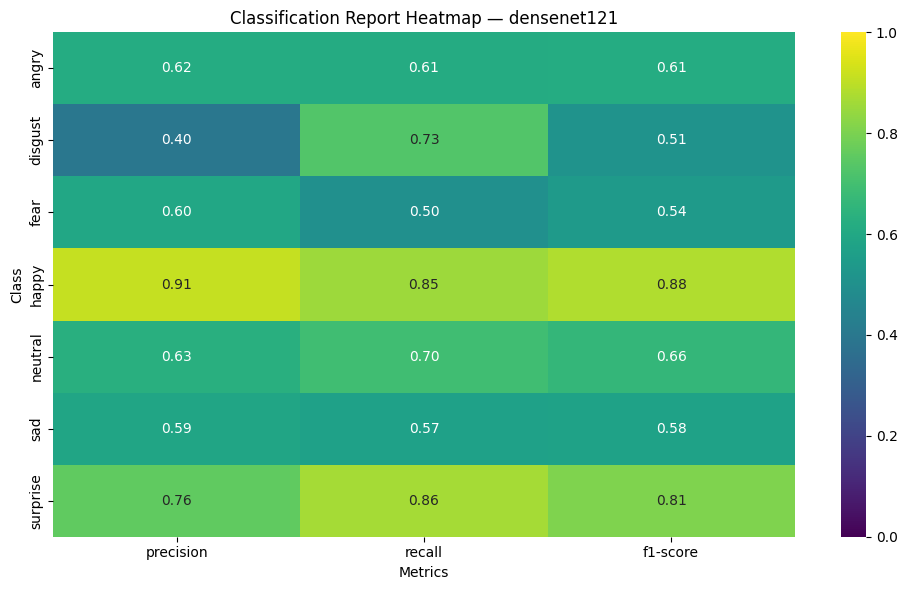

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Model         : shufflenet_v2_x2_0
  Test Accuracy : 0.6780
  F1 Score      : 0.6765
  Precision     : 0.6838
  Recall        : 0.6780


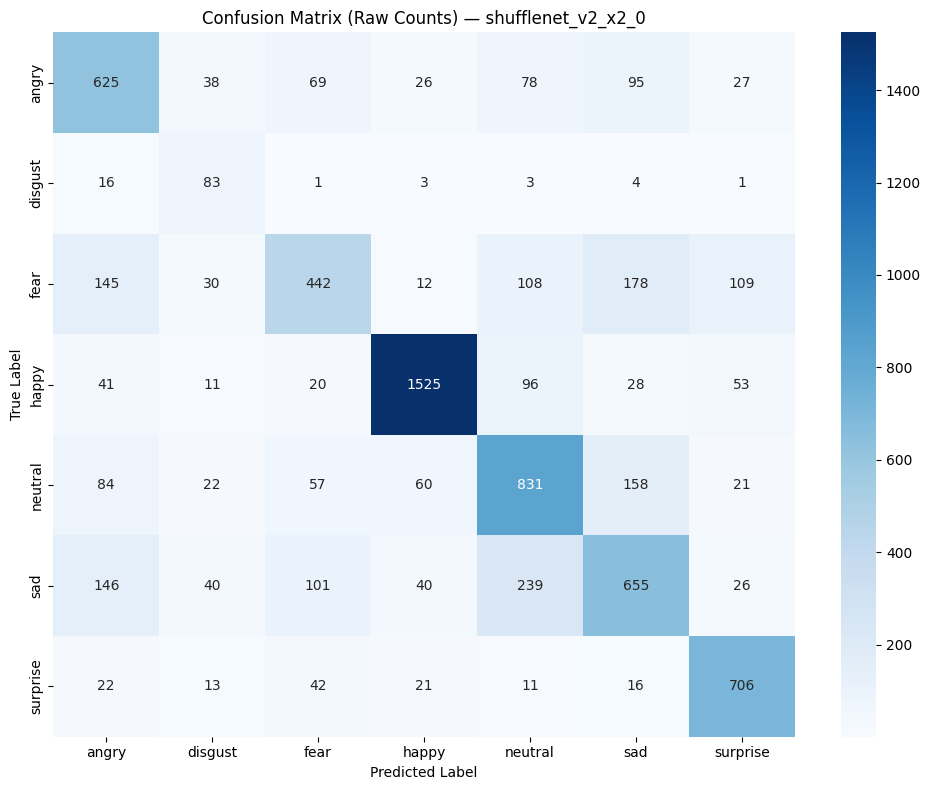

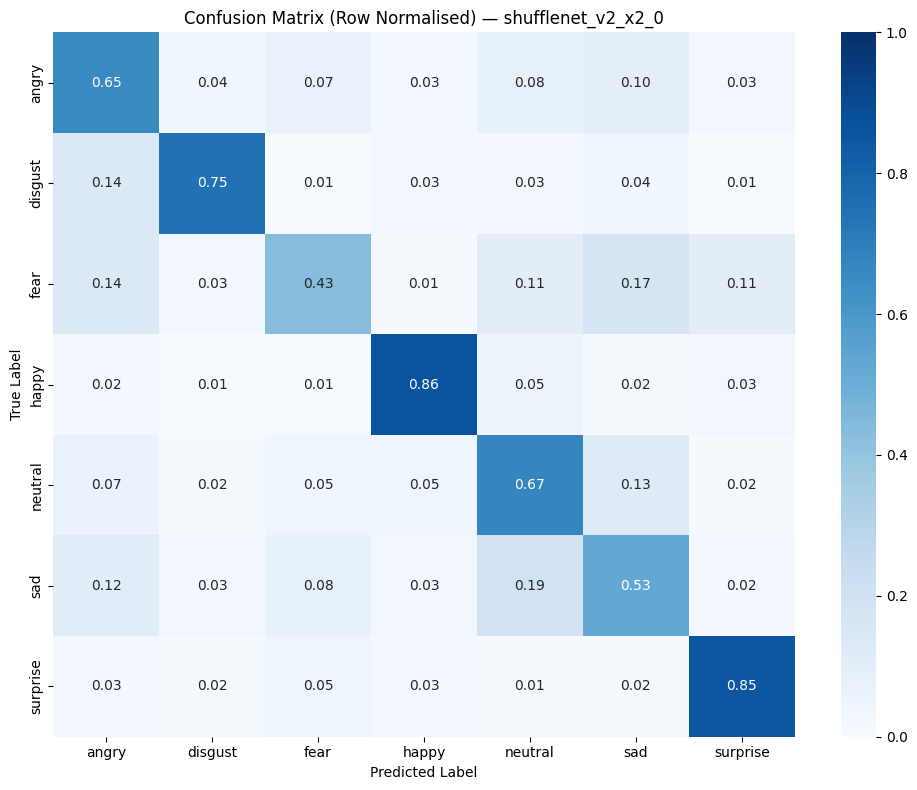

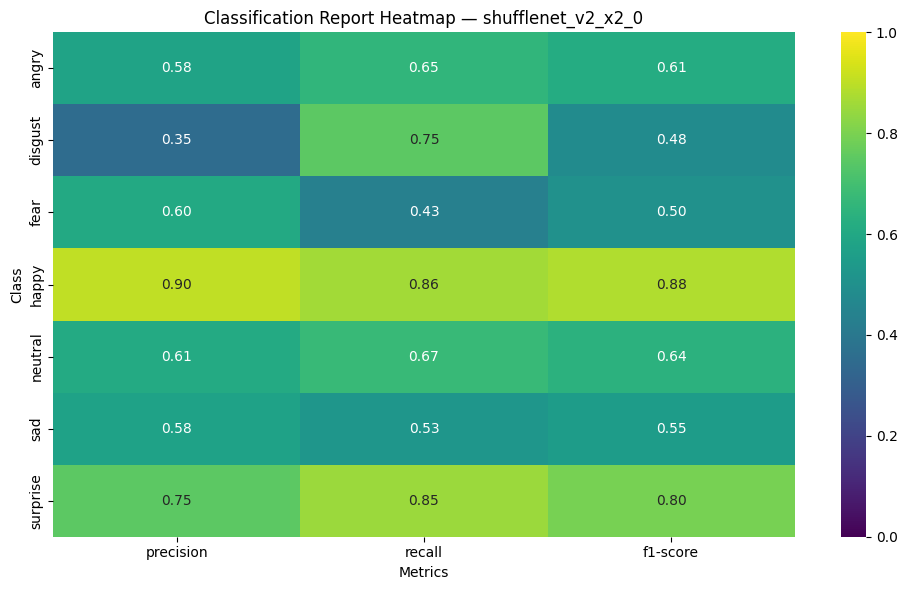

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Model         : resnet18
  Test Accuracy : 0.6718
  F1 Score      : 0.6720
  Precision     : 0.6763
  Recall        : 0.6718


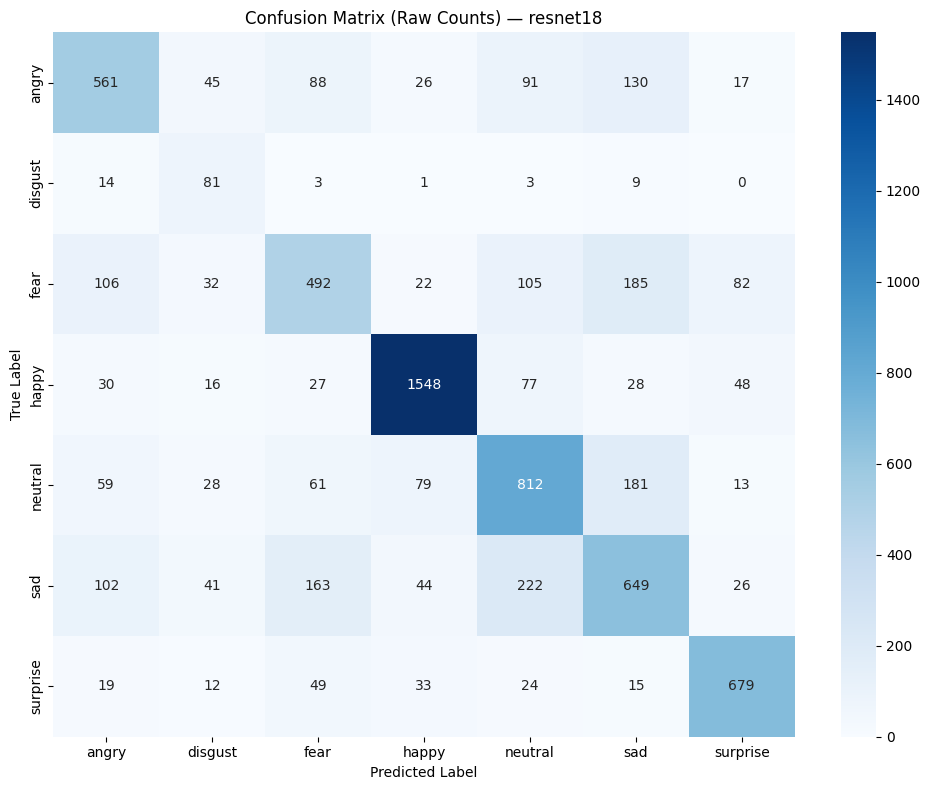

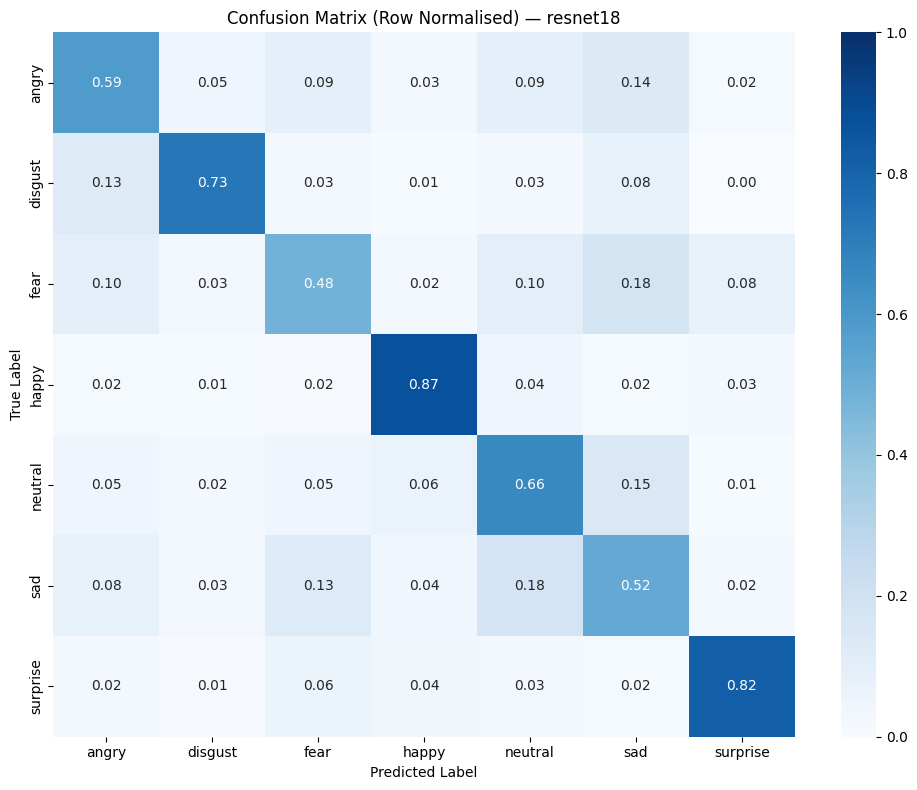

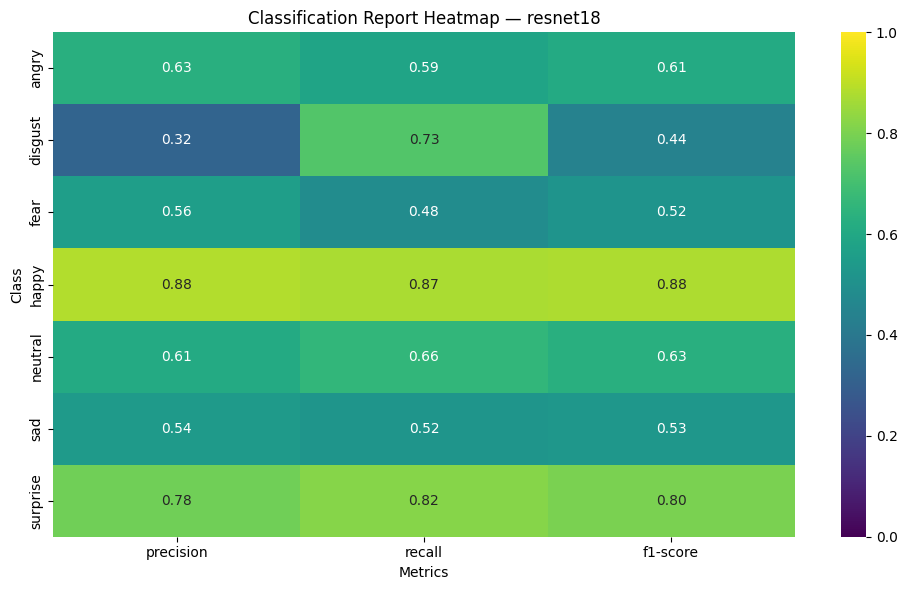

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Model         : regnet_y_400mf
  Test Accuracy : 0.6683
  F1 Score      : 0.6694
  Precision     : 0.6753
  Recall        : 0.6683


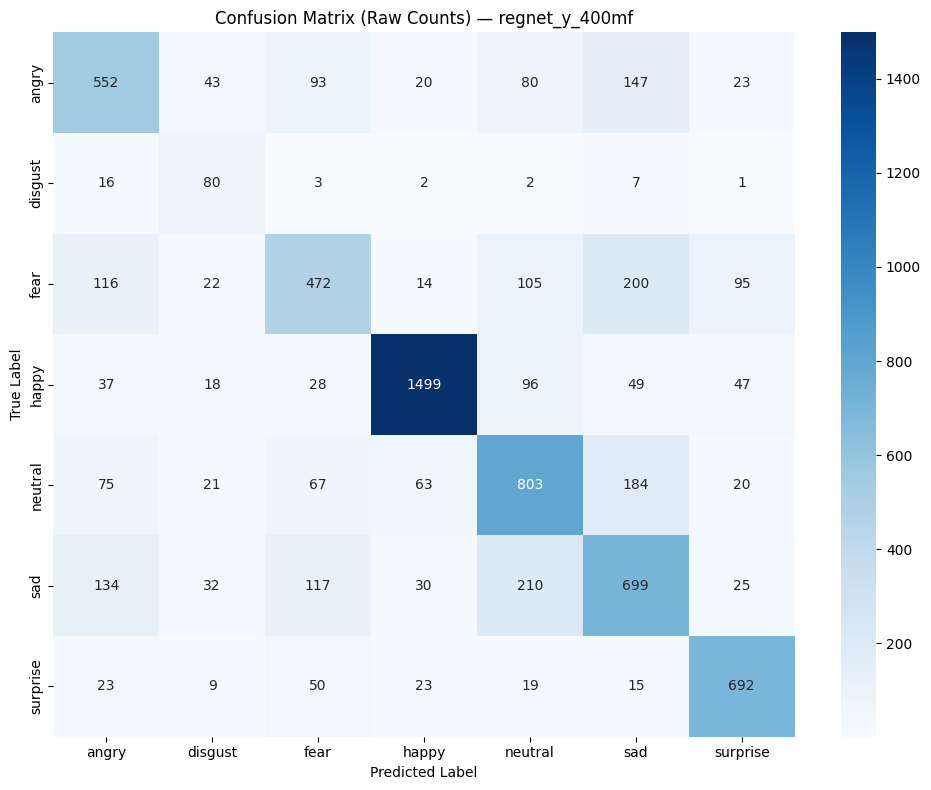

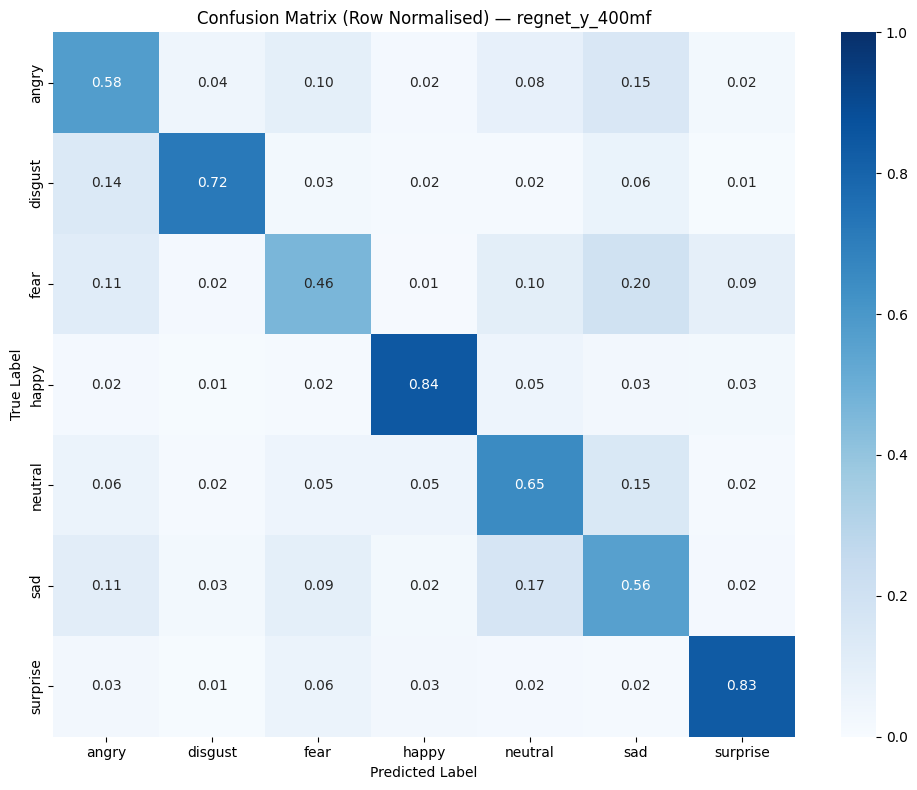

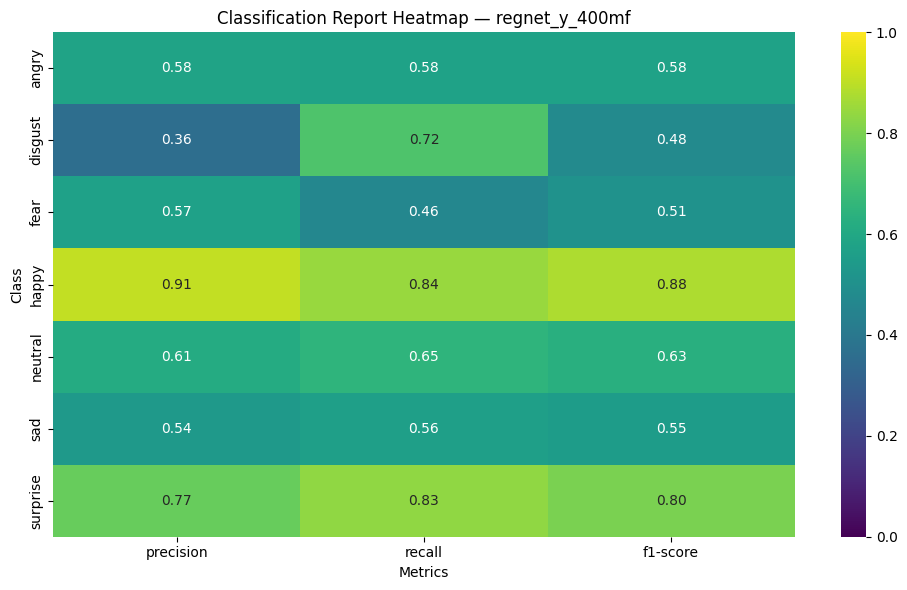

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Model         : mobilenet_v3_small
  Test Accuracy : 0.6558
  F1 Score      : 0.6544
  Precision     : 0.6608
  Recall        : 0.6558


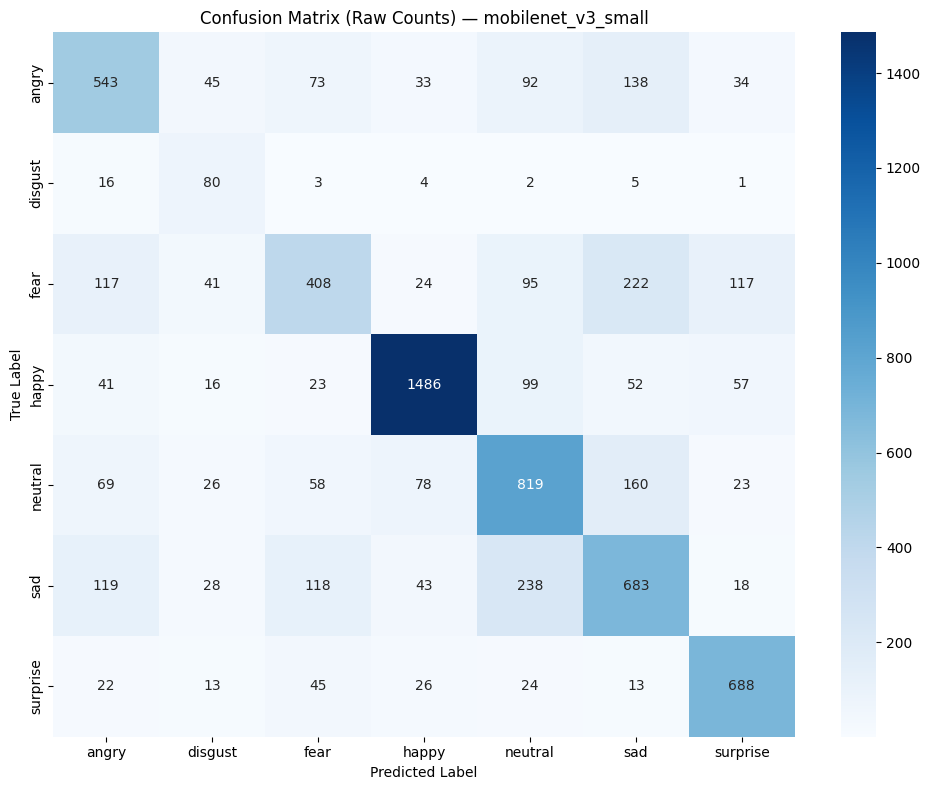

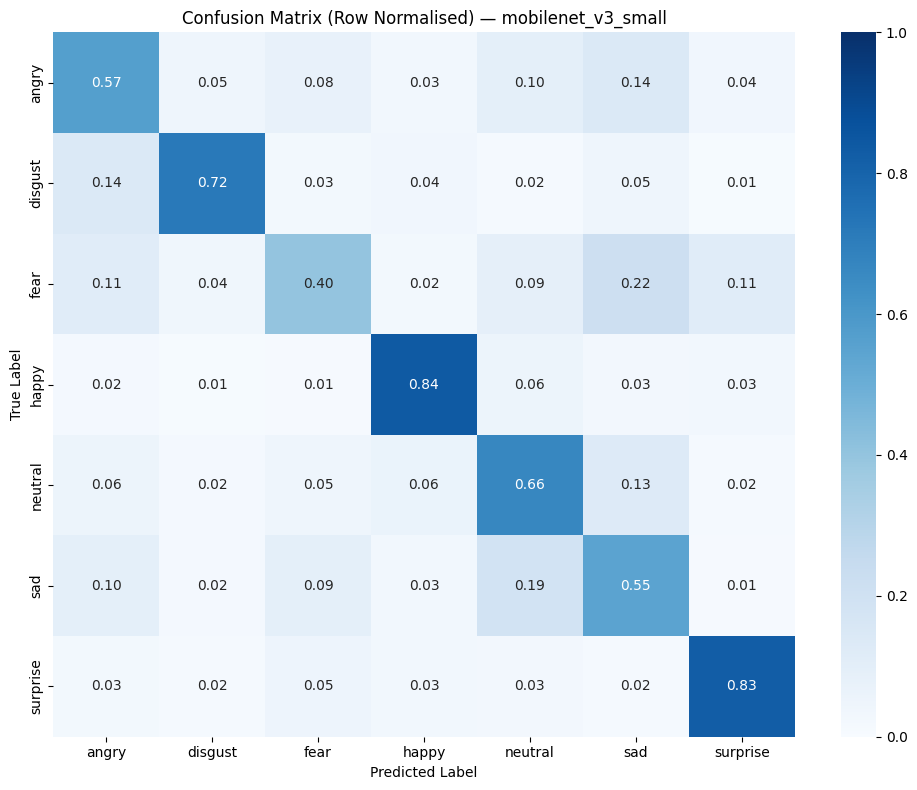

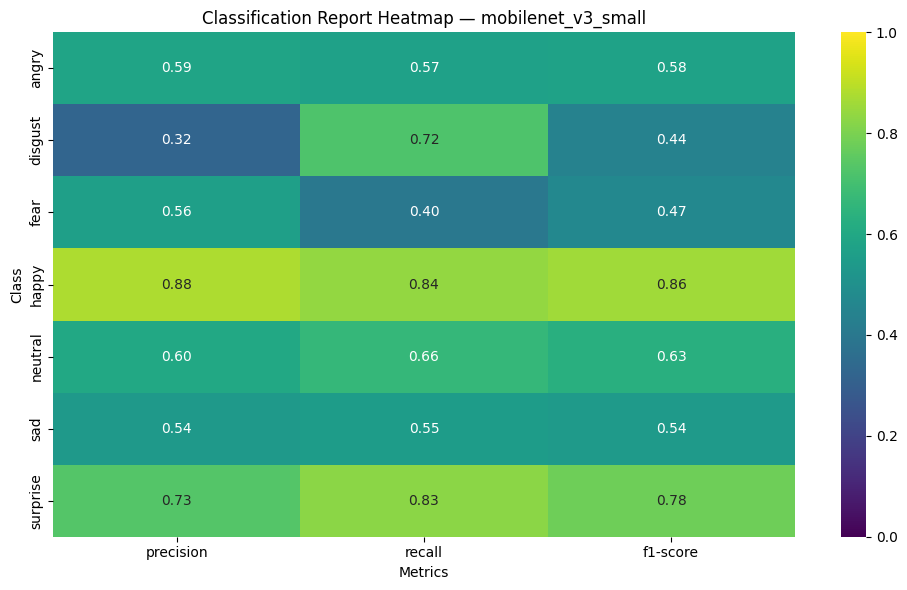

/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worke

  Model         : googlenet
  Test Accuracy : 0.4682
  F1 Score      : 0.4853
  Precision     : 0.5519
  Recall        : 0.4682


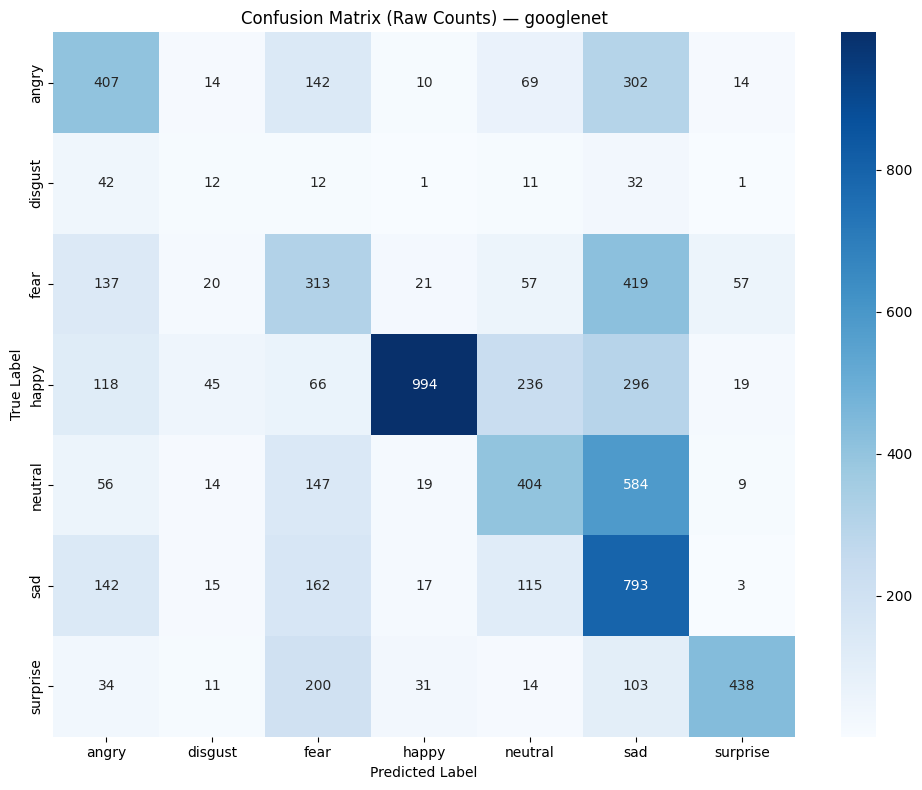

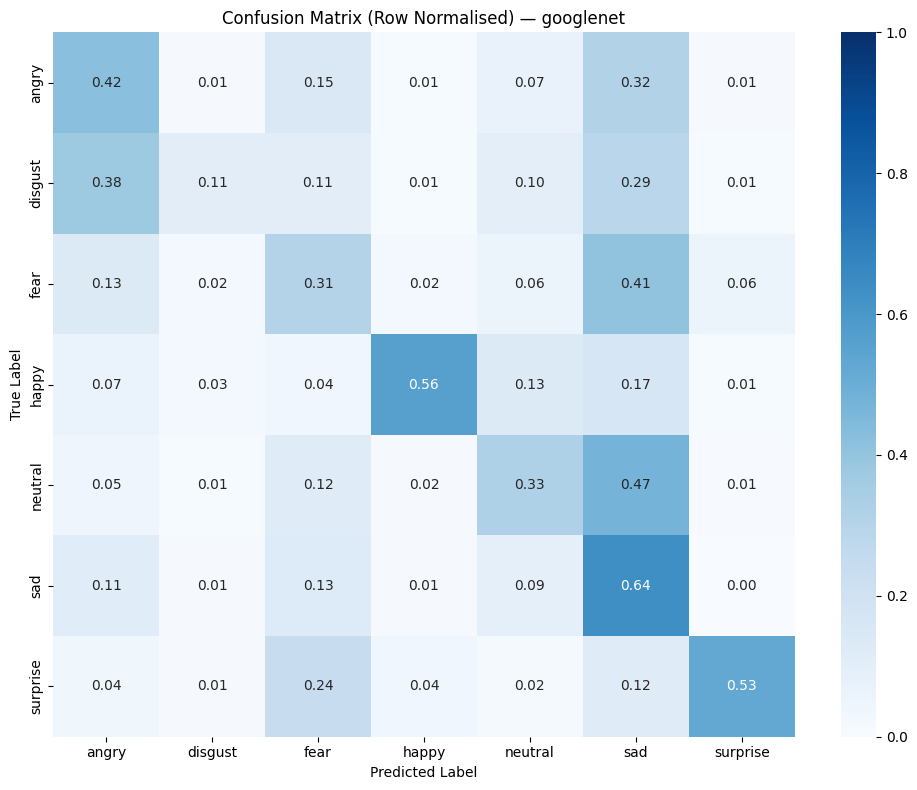

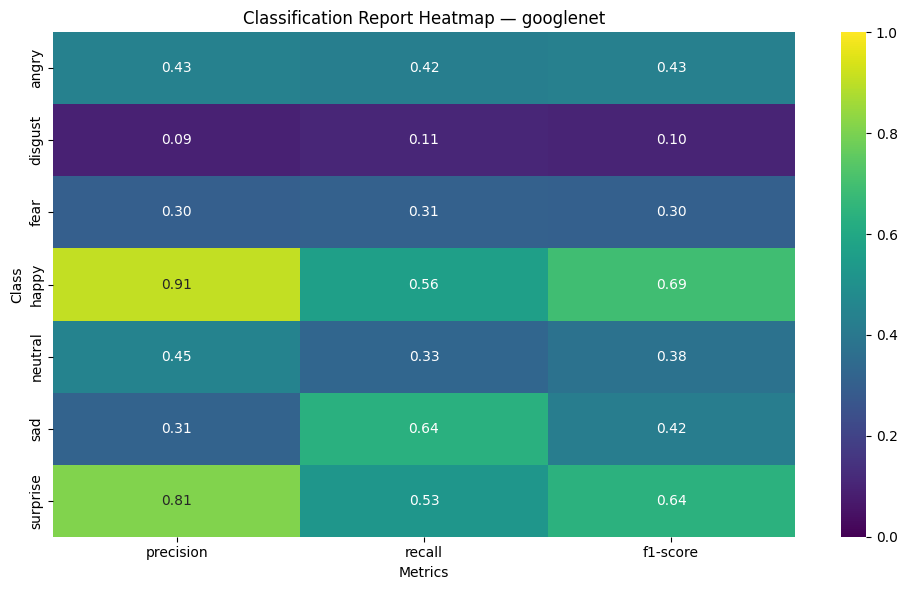

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Model         : efficientnet_v2_s
  Test Accuracy : 0.7051
  F1 Score      : 0.7037
  Precision     : 0.7039
  Recall        : 0.7051


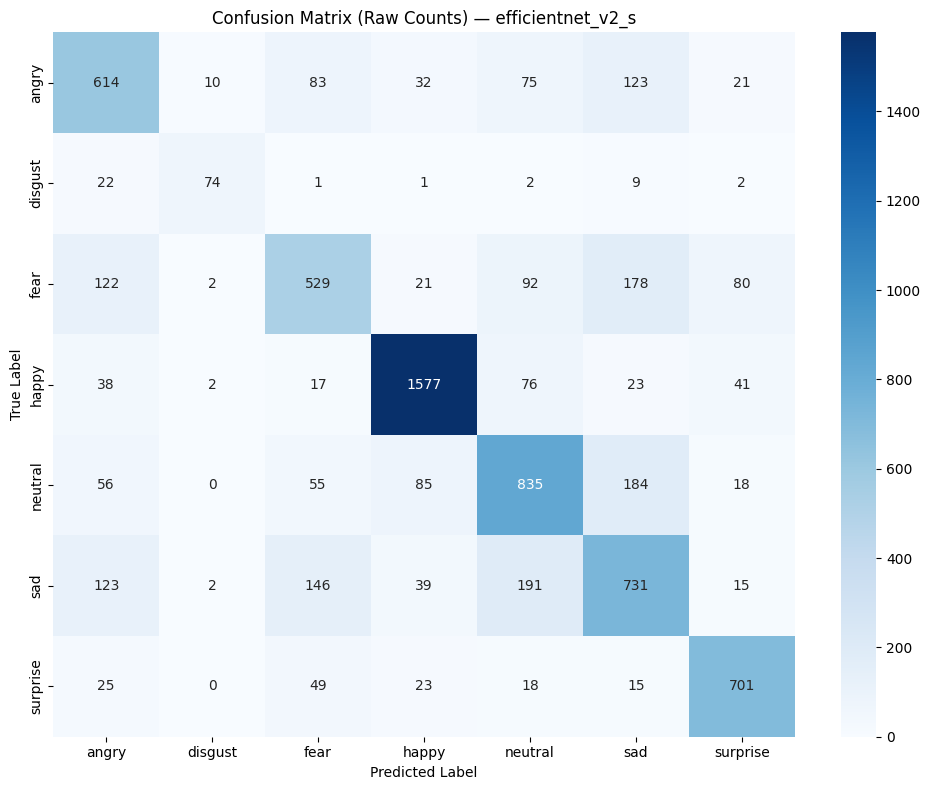

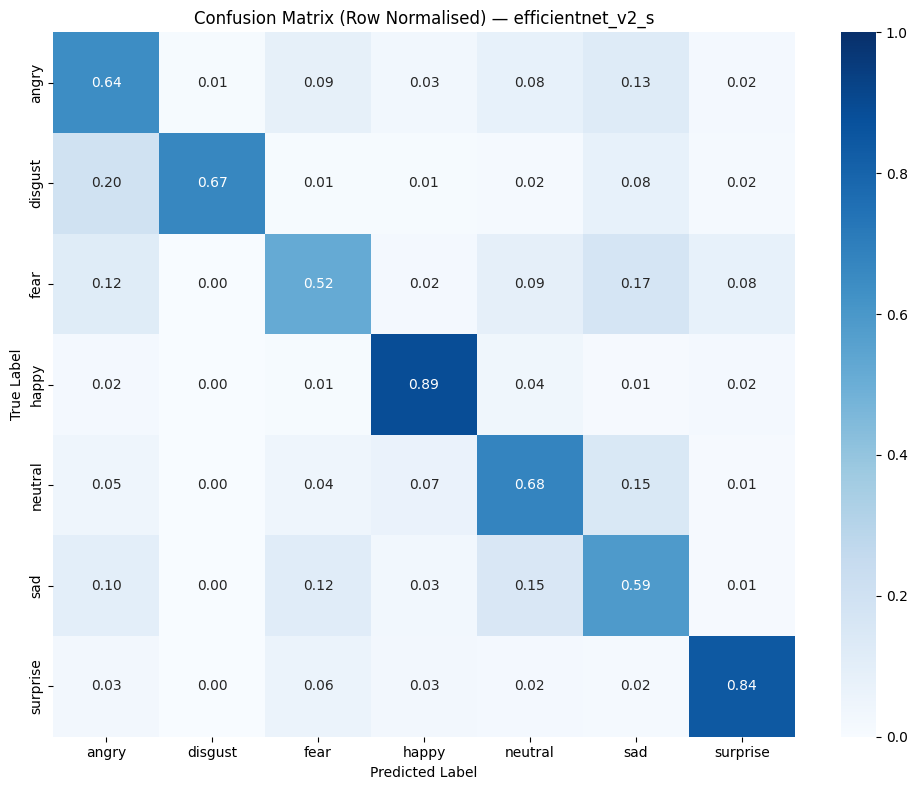

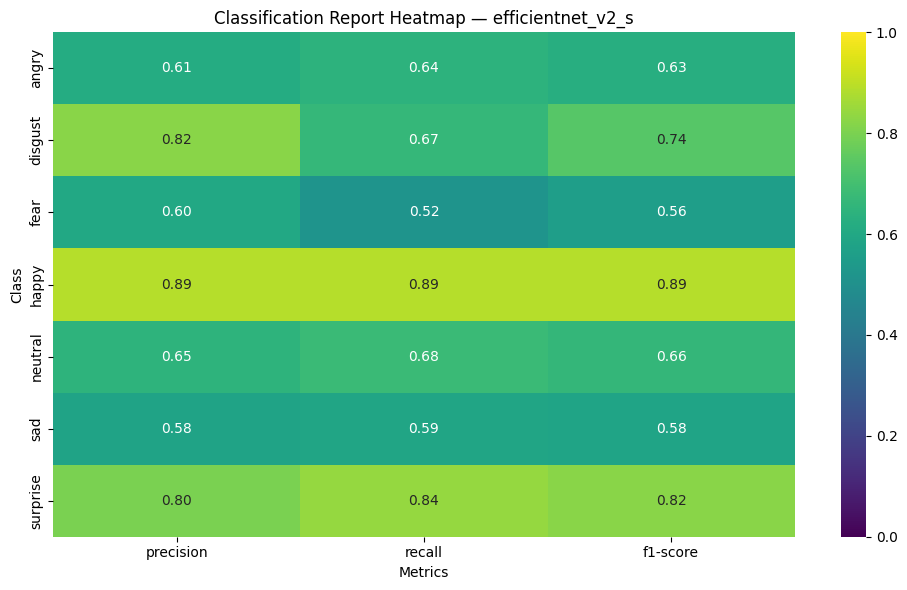

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Model         : alexnet
  Test Accuracy : 0.6695
  F1 Score      : 0.6695
  Precision     : 0.6711
  Recall        : 0.6695


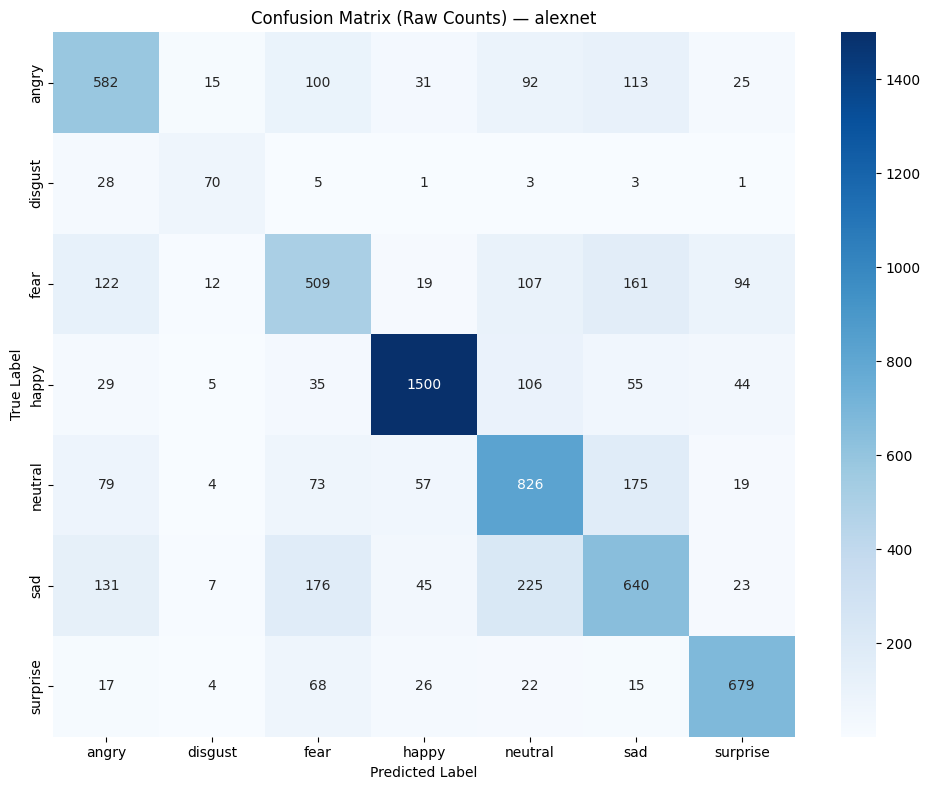

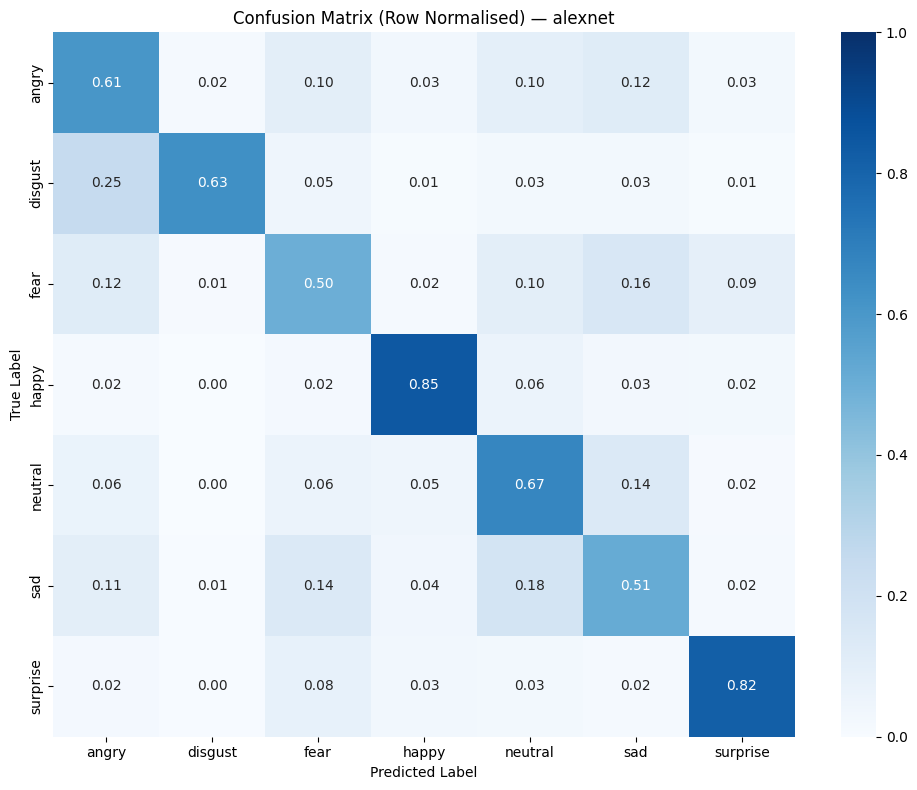

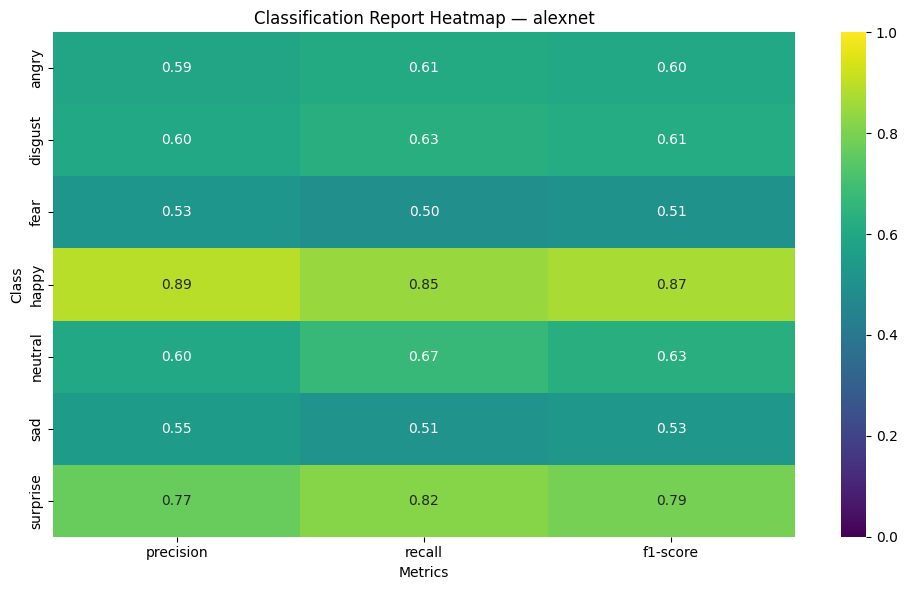

,name,accuracy,f1,precision,recall
7,efficientnet_v2_s,0.705071,0.703722,0.703878,0.705071
1,densenet121,0.692533,0.692412,0.696982,0.692533
2,shufflenet_v2_x2_0,0.678044,0.676462,0.683791,0.678044
3,resnet18,0.671775,0.672022,0.676302,0.671775
8,alexnet,0.669546,0.669509,0.671083,0.669546
4,regnet_y_400mf,0.668292,0.669425,0.675272,0.668292
5,mobilenet_v3_small,0.655754,0.654361,0.660782,0.655754
6,googlenet,0.468236,0.485264,0.551861,0.468236
0,inception_v3,0.270688,0.224081,0.403801,0.270688


In [7]:
results = [evaluate_and_plot(cfg) for cfg in available]
results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
results_df


## Compare training curves (if `history.json` was saved for a model)

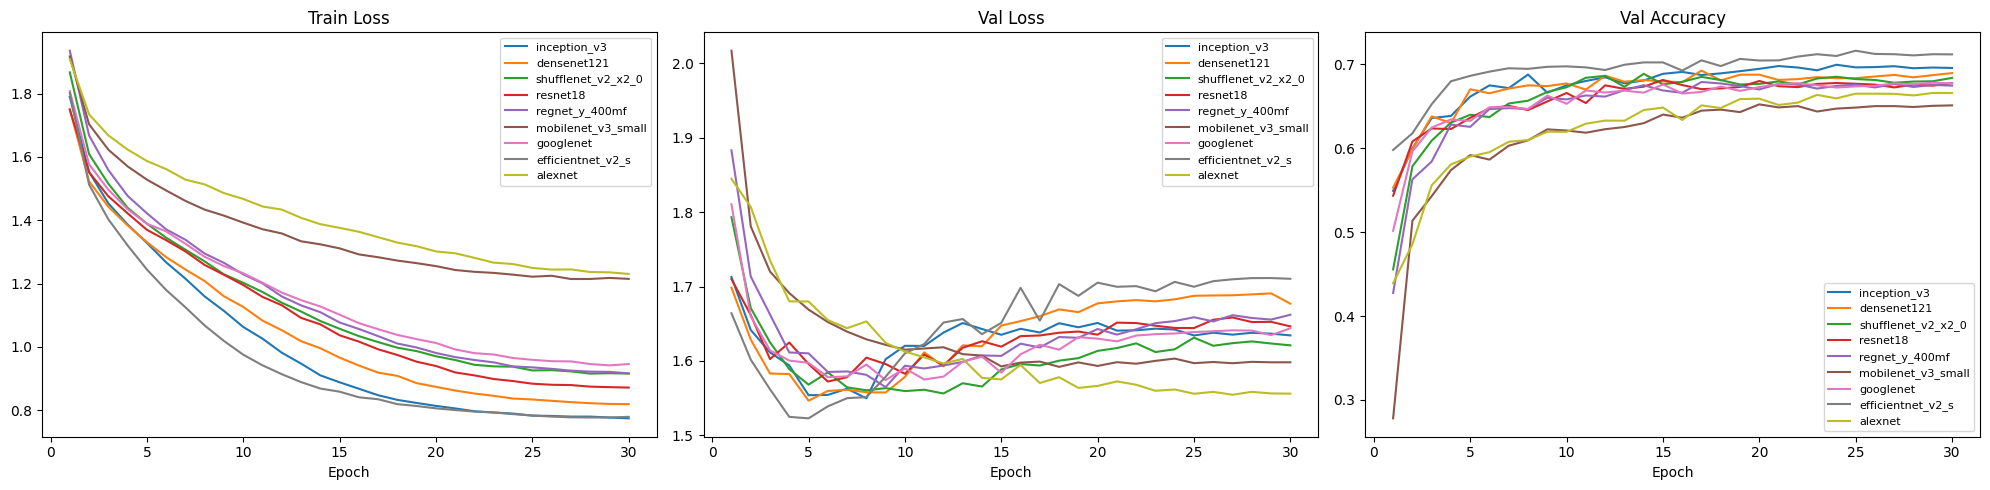

In [8]:
histories = {}
for cfg in available:
    hist_path = os.path.join(paths["weights_dir"], cfg["name"], "history.json")
    if os.path.exists(hist_path):
        with open(hist_path) as f:
            histories[cfg["name"]] = json.load(f)

if histories:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for name, hist in histories.items():
        epochs_ran = range(1, len(hist["train_loss"]) + 1)
        axes[0].plot(epochs_ran, hist["train_loss"], label=name)
        if hist["val_loss"]:
            axes[1].plot(epochs_ran, hist["val_loss"], label=name)
            axes[2].plot(epochs_ran, hist["val_acc"], label=name)
    axes[0].set_title("Train Loss")
    axes[1].set_title("Val Loss")
    axes[2].set_title("Val Accuracy")
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No history.json files found — nothing to plot.")


In [9]:
import os

def verify_split(train_dir, val_dir, expected_ratio=0.8, tolerance=0.02):
    classes = sorted(os.listdir(train_dir))
    total_train, total_val = 0, 0
    any_overlap = False

    print(f"{'Class':<12} {'Train':>7} {'Val':>7} {'Train %':>9}")
    print("-" * 42)

    for cls in classes:
        train_files = set(os.listdir(os.path.join(train_dir, cls)))
        val_files = set(os.listdir(os.path.join(val_dir, cls)))

        n_train, n_val = len(train_files), len(val_files)
        total_train += n_train
        total_val += n_val
        pct = n_train / (n_train + n_val)

        flag = "  ⚠️ off ratio" if abs(pct - expected_ratio) > tolerance else ""
        print(f"{cls:<12} {n_train:>7} {n_val:>7} {pct:>8.1%}{flag}")

        overlap = train_files & val_files
        if overlap:
            any_overlap = True
            print(f"  ⚠️  {len(overlap)} overlapping filenames in '{cls}': {list(overlap)[:5]}")

    overall_pct = total_train / (total_train + total_val)
    print("-" * 42)
    print(f"{'TOTAL':<12} {total_train:>7} {total_val:>7} {overall_pct:>8.1%}")
    print()
    print("✅ Split ratio OK" if abs(overall_pct - expected_ratio) <= tolerance else "⚠️ Split ratio off")
    print("✅ No overlapping filenames" if not any_overlap else "⚠️ Overlap found — see above")


verify_split(paths["train_dir"], paths["val_dir"])

Class          Train     Val   Train %
------------------------------------------
angry           3196     799    80.0%
disgust          349      87    80.0%
fear            3277     820    80.0%
happy           5772    1443    80.0%
neutral         3972     993    80.0%
sad             3864     966    80.0%
surprise        2537     634    80.0%
------------------------------------------
TOTAL          22967    5742    80.0%

✅ Split ratio OK
✅ No overlapping filenames
